# Automated Story Point Estimation via Retrieval-Augmented Generation

> **University:** Universidade do Vale do Rio dos Sinos (UNISINOS)<br />
> **Program:** Pós-graduação em Inteligência Artificial Aplicada<br />
> **Course:** Inteligência Artificial Generativa<br />
> **Author:** Augusto Stahlschmidt e Eduardo Moraes Macedo<br />
> **Date:** November 25, 2025  

---

## 1. Introduction & Objectives

**Problem:**  
Manual story point estimation in agile teams is inherently subjective. Planning Poker sessions depend on individual experience and interpersonal dynamics, producing estimates that vary significantly across teams and sprints. When historical project data is available, it represents an untapped resource for producing more consistent, data-driven estimates.

**Task Type:**  
Retrieval-Augmented Generation (RAG) with structured few-shot prompting.

**System Overview:**  
This notebook implements a full RAG pipeline that:
1. Encodes historical user stories into dense semantic vectors using a pretrained transformer model.
2. Indexes them in a FAISS vector store for efficient similarity search.
3. Retrieves the most semantically similar historical stories for any new input.
4. Constructs a structured few-shot prompt and sends it to a large language model (LLM).
5. Parses the LLM response into a structured estimate with confidence level and justification.

**Business Objective:**  
Build an automated estimation copilot that reduces estimation variance, shortens Planning Poker ceremonies, and provides traceable justifications for each estimate.

**Analytical Goal:**  
Implement the full RAG pipeline and evaluate it quantitatively against a held-out test set, comparing against a majority-class baseline and a TF-IDF + KNN retrieval baseline.

**Primary Evaluation Metrics:**  
- Mean Absolute Error (MAE)
- Accuracy within ±1 story point

**Success Criteria:**  
- Accuracy within ±1 story point above 60%.
- Consistent, structured JSON justifications from the LLM for every estimate.

## 2. Setup & Imports

In [ ]:
%pip install -q pandas numpy sentence-transformers faiss-cpu datasets transformers anthropic scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import re
import json
import getpass
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sentence_transformers import SentenceTransformer
import faiss
import anthropic
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error

# Reproducibility
SEED = 42
np.random.seed(SEED)
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

# Pipeline configuration
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
LLM_MODEL_NAME = "claude-haiku-4-5-20251001"
EMBEDDING_CACHE_PATH = "neodataset_fibonacci_embeddings.npz"
FIBONACCI_SCALE = [1, 2, 3, 5, 8, 13, 21]
K_RETRIEVAL = 10

print("Environment ready")
print("Pandas {} | NumPy {}".format(pd.__version__, np.__version__))

Environment ready
Pandas 3.0.1 | NumPy 2.4.4


## 3. Data Loading & Initial Inspection

**Dataset:**<br>
[Hugging Face Datasets — giseldo/neodataset](https://huggingface.co/datasets/giseldo/neodataset)

**Description:**  
NeoDataset is a corpus of real-world software project issues collected from GitHub and Jira, annotated with story point estimates assigned by development teams. It spans multiple project types including mobile apps, web platforms, and backend services.

**Features:**

| # | Feature | Type | Description |
|---|---------|------|-------------|
| 1 | idproject | int | Project identifier |
| 2 | issuekey | int | Unique issue identifier |
| 3 | created | string | Issue creation timestamp |
| 4 | title | string | Short issue title |
| 5 | description | string | Detailed issue description (partially missing) |
| 6 | storypoints | int | Story points estimated by the team |

**Unit of Analysis:** Individual user story or software issue.

**Target Variable:** `storypoints`, the Fibonacci-scale effort estimate assigned by the team.

**Notes:**
- Story point values span beyond the standard Fibonacci scale due to team-specific conventions.
- The dataset comes pre-split as a single train split; we perform our own train/test split.

In [ ]:
dataset = load_dataset("giseldo/neodataset")
df_raw = dataset["train"].to_pandas()

print("Raw dataset shape:", df_raw.shape)
display(df_raw.head())

print("\nData types:")
display(df_raw.dtypes)

print("\nMissing values:")
display(df_raw.isna().sum())

Raw dataset shape: (20479, 6)


,idproject,issuekey,created,title,description,storypoints
0,10152778,19541701,2019-03-28 15:04:16.070,(feat): change 'from' email address to 'no-rep...,Emails should not point to info@minds.com,1.0
1,10152778,19273465,2019-03-20 02:11:19.496,(bug): Link previews disappear when editing a ...,### Summary\r\n\r\nWhen editing a status post ...,3.0
2,10152778,18774779,2019-03-04 11:21:14.993,(bug): subscribed blog post duplicates filling...,NaN,2.0
3,10152778,18438523,2019-02-20 16:14:17.411,(bug): Cant delete a reply to a comment on a b...,"### Summary\r\n\r\nOn ones own blog post, whil...",5.0
4,10152778,18177704,2019-02-12 16:55:06.846,Counter in group convo-feeds counts 2 seconds ...,### Summary\r\n\r\nWhen a comment is is left i...,5.0



Data types:


idproject        int64
issuekey         int64
created            str
title              str
description        str
storypoints    float64
dtype: object


Missing values:


idproject         0
issuekey          0
created           0
title             0
description    1625
storypoints       5
dtype: int64

In [ ]:
print("Story point summary statistics:")
display(df_raw["storypoints"].describe())

sp_unique = sorted(df_raw["storypoints"].dropna().astype(int).unique().tolist())
print("\nDistinct story point values ({} total):".format(len(sp_unique)))
print(sp_unique)

Story point summary statistics:


count    20474.000000
mean         5.989401
std         17.151408
min          0.000000
25%          2.000000
50%          3.000000
75%          6.000000
max        300.000000
Name: storypoints, dtype: float64


Distinct story point values (82 total):
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28, 30, 32, 33, 34, 35, 36, 38, 40, 42, 44, 45, 46, 48, 50, 52, 53, 54, 56, 58, 60, 62, 64, 68, 70, 72, 74, 76, 78, 80, 82, 84, 86, 96, 100, 102, 106, 114, 128, 136, 140, 144, 150, 156, 162, 164, 172, 174, 182, 186, 200, 204, 234, 260, 268, 300]


## 4. Exploratory Data Analysis

Goals:
- Understand the story point distribution and identify class imbalance.
- Assess description coverage and text quality.
- Explore the relationship between text length and effort estimates.
- Characterize estimation patterns across different projects.
- Quantify the proportion of issues that follow the Fibonacci scale.

In [ ]:
df = df_raw.dropna(subset=["storypoints"]).copy()
df["storypoints"] = df["storypoints"].astype(int)
df["title"] = df["title"].fillna("")
df["description"] = df["description"].fillna("")
df["text"] = df["title"] + " | " + df["description"]
df["text_length"] = df["text"].str.len()
df["has_description"] = df["description"].str.strip().ne("")
df = df.reset_index(drop=True)

print("Records after dropping rows with missing story points: {:,}".format(len(df)))
print("Projects covered: {}".format(df["idproject"].nunique()))
print("Story point range: {} to {}".format(df["storypoints"].min(), df["storypoints"].max()))

Records after dropping rows with missing story points: 20,474
Projects covered: 33
Story point range: 0 to 300


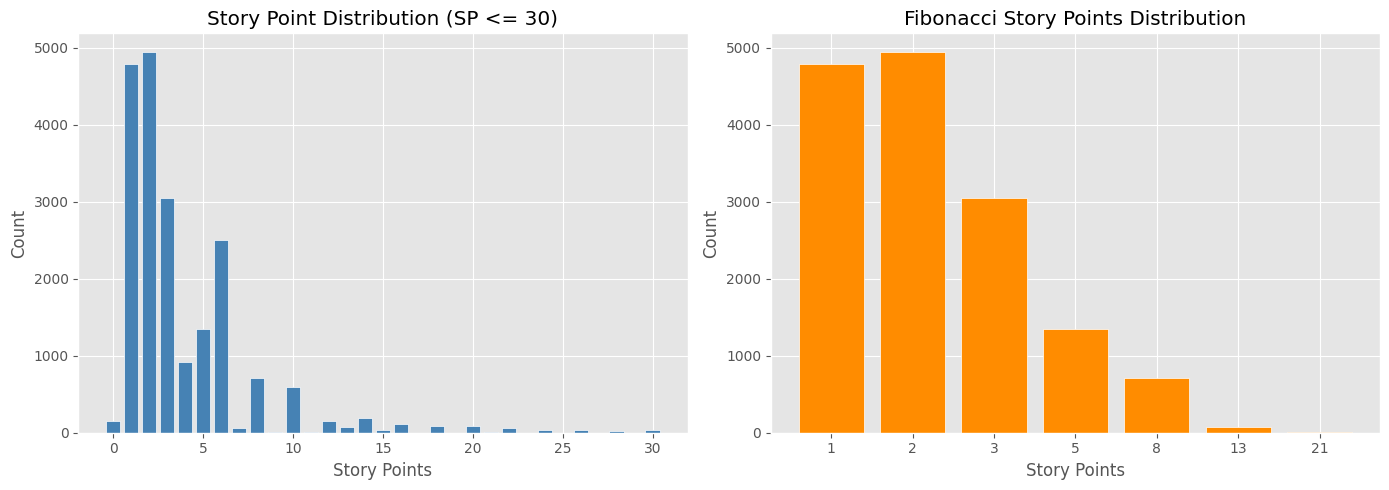

Records on Fibonacci scale: 72.9% (14,920 records)
Class 1 SP dominates, indicating most tasks are small-to-medium effort.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution capped for readability
sp_all = df[df["storypoints"] <= 30]["storypoints"].value_counts().sort_index()
axes[0].bar(sp_all.index, sp_all.values, color="steelblue", edgecolor="white")
axes[0].set_title("Story Point Distribution (SP <= 30)")
axes[0].set_xlabel("Story Points")
axes[0].set_ylabel("Count")

# Fibonacci values only
fib_counts = df[df["storypoints"].isin(FIBONACCI_SCALE)]["storypoints"].value_counts().sort_index()
axes[1].bar([str(x) for x in fib_counts.index], fib_counts.values, color="darkorange", edgecolor="white")
axes[1].set_title("Fibonacci Story Points Distribution")
axes[1].set_xlabel("Story Points")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

fib_pct = df["storypoints"].isin(FIBONACCI_SCALE).mean()
print("Records on Fibonacci scale: {:.1%} ({:,} records)".format(fib_pct, int(fib_pct * len(df))))
print("Class 1 SP dominates, indicating most tasks are small-to-medium effort.")

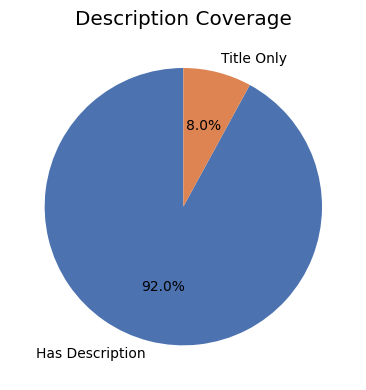

Issues with description: 18,845
Title-only issues: 1,629
Note: the embedding model processes both title and description together.


In [ ]:
desc_counts = df["has_description"].value_counts()
n_with = desc_counts.get(True, 0)
n_without = desc_counts.get(False, 0)

fig, ax = plt.subplots(figsize=(5, 4))
ax.pie(
    [n_with, n_without],
    labels=["Has Description", "Title Only"],
    autopct="%1.1f%%",
    colors=["#4C72B0", "#DD8452"],
    startangle=90
)
ax.set_title("Description Coverage")
plt.tight_layout()
plt.show()

print("Issues with description: {:,}".format(n_with))
print("Title-only issues: {:,}".format(n_without))
print("Note: the embedding model processes both title and description together.")

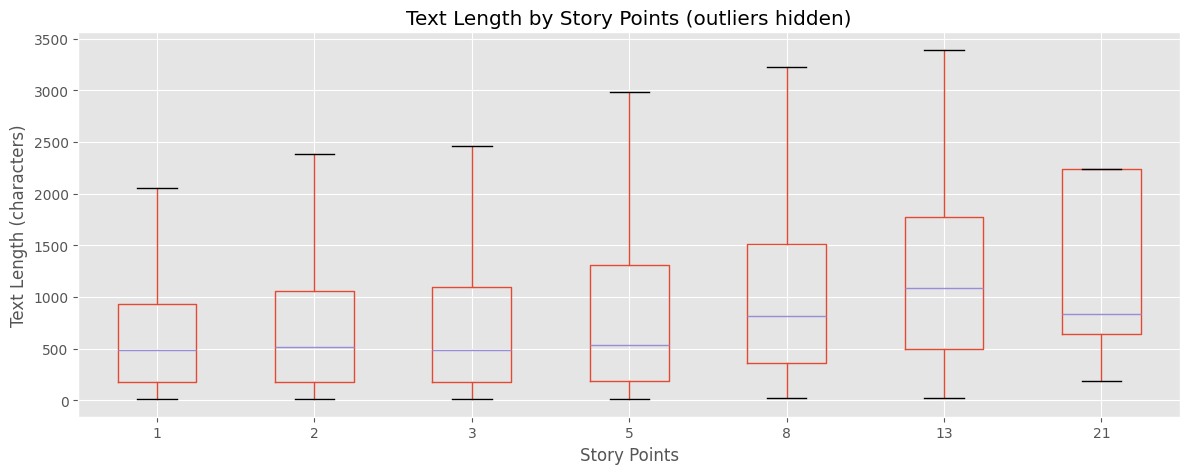

Average text length by story points:


,avg_text_length
storypoints,
1,840.0
2,870.0
3,850.0
5,979.0
8,1292.0
13,1607.0
21,1825.0


In [ ]:
df_fib = df[df["storypoints"].isin(FIBONACCI_SCALE)].copy()

fig, ax = plt.subplots(figsize=(12, 5))
df_fib.boxplot(column="text_length", by="storypoints", ax=ax, showfliers=False)
ax.set_title("Text Length by Story Points (outliers hidden)")
ax.set_xlabel("Story Points")
ax.set_ylabel("Text Length (characters)")
plt.suptitle("")
plt.tight_layout()
plt.show()

print("Average text length by story points:")
display(df_fib.groupby("storypoints")["text_length"].mean().rename("avg_text_length").round(0).to_frame())

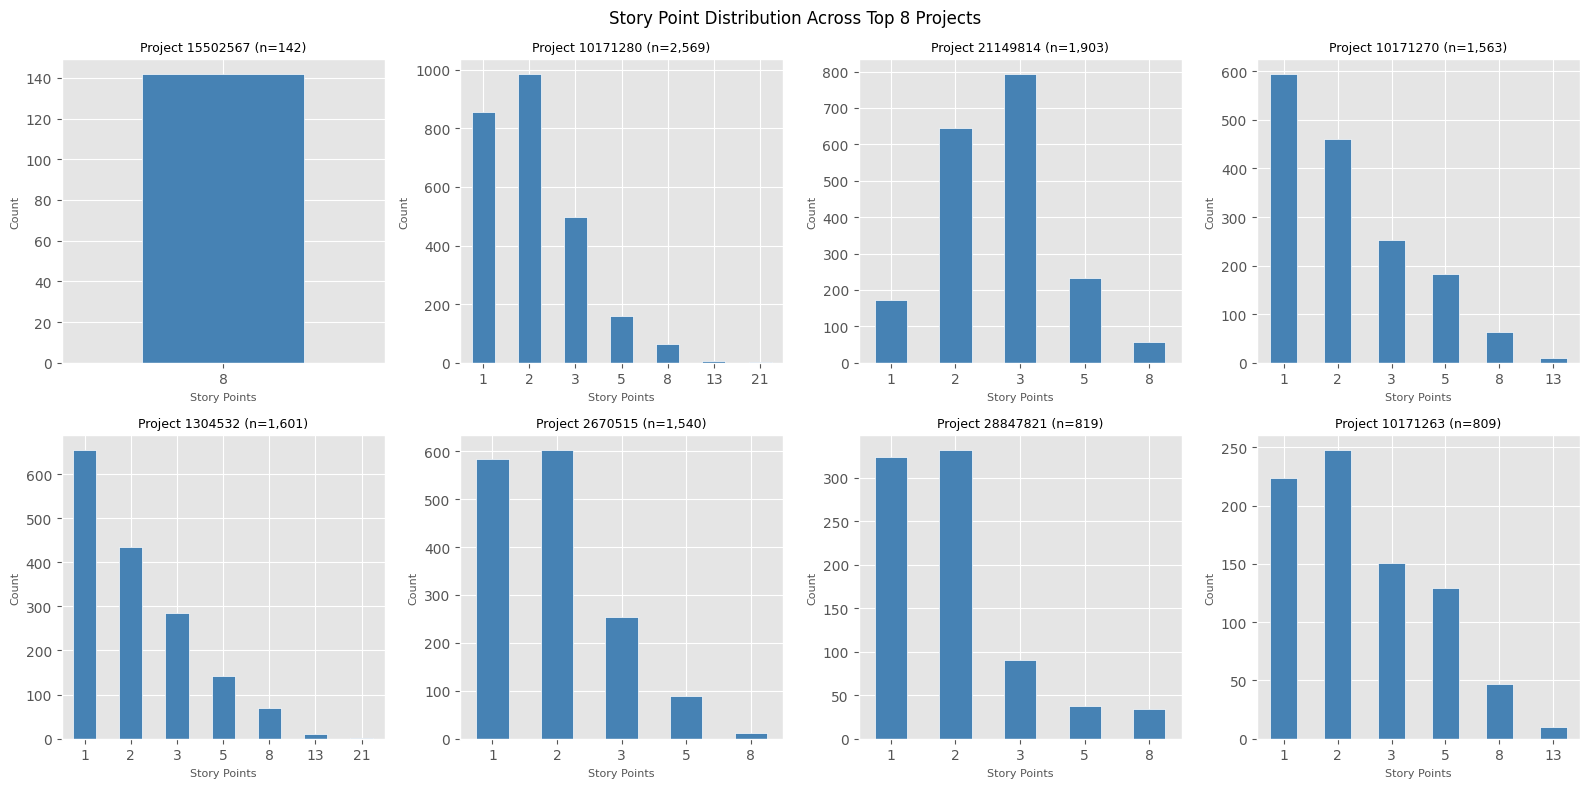

Estimation patterns vary across projects, reflecting different team conventions and task granularity.


In [ ]:
top_projects = df["idproject"].value_counts().head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, pid in zip(axes.flatten(), top_projects):
    sub = df[(df["idproject"] == pid) & (df["storypoints"].isin(FIBONACCI_SCALE))]["storypoints"]
    if len(sub) == 0:
        ax.set_visible(False)
        continue
    sub.value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title("Project {} (n={:,})".format(pid, len(sub)), fontsize=9)
    ax.set_xlabel("Story Points", fontsize=8)
    ax.set_ylabel("Count", fontsize=8)
    ax.tick_params(axis="x", rotation=0)

plt.suptitle("Story Point Distribution Across Top 8 Projects", fontsize=12)
plt.tight_layout()
plt.show()
print("Estimation patterns vary across projects, reflecting different team conventions and task granularity.")

## 5. Preprocessing & Embedding Generation

Operations performed:

- Filter to the standard Fibonacci story point scale [1, 2, 3, 5, 8, 13, 21], covering the vast majority of agile teams and reducing noise from non-standard scales.
- Construct the `text` field by concatenating title and description with a separator.
- Perform a stratified train/test split (95/5) so that every Fibonacci class is represented in both sets.
- Encode all texts into 384-dimensional dense vectors using `all-MiniLM-L6-v2`, a lightweight but effective sentence transformer.
- Build a FAISS flat inner-product index on the training embeddings only.

Preventing data leakage: the FAISS index is built exclusively from training examples. The retrieval system therefore cannot return the exact test story as its own nearest neighbor, ensuring that evaluation reflects real-world generalization.

In [ ]:
df_filtered = df[df["storypoints"].isin(FIBONACCI_SCALE)].copy().reset_index(drop=True)

print("Records after Fibonacci filter: {:,}".format(len(df_filtered)))
print("\nClass distribution:")
display(
    df_filtered["storypoints"]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
    .assign(pct=lambda x: (x["count"] / x["count"].sum() * 100).round(1))
)

Records after Fibonacci filter: 14,921

Class distribution:


,count,pct
storypoints,,
1,4794,32.1
2,4940,33.1
3,3054,20.5
5,1348,9.0
8,709,4.8
13,71,0.5
21,5,0.0


In [ ]:
all_indices = np.arange(len(df_filtered))
train_idx, test_idx = train_test_split(
    all_indices,
    test_size=0.05,
    random_state=SEED,
    stratify=df_filtered["storypoints"],
)

train_df = df_filtered.iloc[train_idx].reset_index(drop=True)
test_df = df_filtered.iloc[test_idx].reset_index(drop=True)

print("Train: {:,} stories | Test: {:,} stories".format(len(train_df), len(test_df)))
print("\nTest set class distribution:")
display(test_df["storypoints"].value_counts().sort_index().rename("count").to_frame())

Train: 14,174 stories | Test: 747 stories

Test set class distribution:


,count
storypoints,
1,240
2,247
3,153
5,67
8,36
13,4


In [ ]:
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
EMB_DIM = embedding_model.get_sentence_embedding_dimension()

print("Model loaded:", EMBEDDING_MODEL_NAME)
print("Embedding dimension:", EMB_DIM)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded: sentence-transformers/all-MiniLM-L6-v2
Embedding dimension: 384


In [ ]:
def generate_embeddings(texts):
    return embedding_model.encode(
        texts,
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    ).astype("float32")


if os.path.exists(EMBEDDING_CACHE_PATH):
    cache = np.load(EMBEDDING_CACHE_PATH)
    all_embeddings = cache["embeddings"].astype("float32")
    if len(all_embeddings) == len(df_filtered):
        print("Embeddings loaded from cache: {}".format(all_embeddings.shape))
    else:
        print("Cache size mismatch ({} vs {}). Regenerating...".format(
            len(all_embeddings), len(df_filtered)
        ))
        all_embeddings = generate_embeddings(df_filtered["text"].tolist())
        np.savez(EMBEDDING_CACHE_PATH, embeddings=all_embeddings,
                 labels=df_filtered["storypoints"].values)
else:
    print("Cache not found. Generating embeddings (this may take several minutes)...")
    all_embeddings = generate_embeddings(df_filtered["text"].tolist())
    np.savez(EMBEDDING_CACHE_PATH, embeddings=all_embeddings,
             labels=df_filtered["storypoints"].values)
    print("Embeddings cached at:", EMBEDDING_CACHE_PATH)

train_embeddings = all_embeddings[train_idx]
test_embeddings = all_embeddings[test_idx]

print("Train embeddings: {}".format(train_embeddings.shape))
print("Test embeddings:  {}".format(test_embeddings.shape))

Cache not found. Generating embeddings (this may take several minutes)...


Batches:   0%|          | 0/234 [00:00<?, ?it/s]

Embeddings cached at: neodataset_fibonacci_embeddings.npz
Train embeddings: (14174, 384)
Test embeddings:  (747, 384)


In [ ]:
faiss_index = faiss.IndexFlatIP(EMB_DIM)
faiss_index.add(train_embeddings)

print("FAISS index built: {:,} vectors (dim={})".format(faiss_index.ntotal, EMB_DIM))
print("Index type: IndexFlatIP (exact cosine similarity for L2-normalized vectors)")

FAISS index built: 14,174 vectors (dim=384)
Index type: IndexFlatIP (exact cosine similarity for L2-normalized vectors)


## 6. RAG Pipeline Implementation

The pipeline operates in three stages:

Stage 1, Semantic Retrieval: The query story is encoded into a dense vector and compared against all indexed training stories using cosine similarity (inner product on L2-normalized vectors via FAISS). The top-k most similar stories are returned with their similarity scores.

Stage 2, Prompt Construction: Retrieved examples are formatted as a structured few-shot prompt. Each example includes its text, assigned story points, and similarity score. The prompt instructs the LLM to reason from examples explicitly and produce output in a prescribed JSON schema.

Stage 3, LLM Generation: The prompt is sent to LLM. The JSON response is parsed and the estimate is snapped to the nearest Fibonacci value if needed.

In [ ]:
def retrieve_similar(query_text, k=K_RETRIEVAL):
    """Return the k most semantically similar training stories."""
    query_emb = embedding_model.encode(
        [query_text], normalize_embeddings=True
    ).astype("float32")
    scores, indices = faiss_index.search(query_emb, k)
    return [
        {
            "text": train_df.loc[i, "text"],
            "story_points": int(train_df.loc[i, "storypoints"]),
            "similarity": float(s),
        }
        for s, i in zip(scores[0], indices[0])
    ]

In [ ]:
_PROMPT_PARTS = [
    "You are an expert agile agent specializing in story point estimation.",
    "",
    "Estimate story points for the new user story below, using only the Fibonacci scale: 1, 2, 3, 5, 8, 13, 21.",
    "",
    "=== NEW USER STORY ===",
    "{story}",
    "",
    "=== SIMILAR HISTORICAL EXAMPLES ===",
    "{examples}",
    "",
    "=== INSTRUCTIONS ===",
    "1. Analyze the scope and technical complexity of the new story.",
    "2. Compare it with the historical examples, noting similarities and differences in complexity.",
    "3. Choose a story point value from the Fibonacci scale.",
    "4. State your confidence: low (high uncertainty), medium, or high (clear pattern match).",
    "5. Justify your estimate by explicitly referencing which examples influenced the decision.",
    "",
    'Respond ONLY with valid JSON in this exact format:',
    '{{',
    '  "estimate": <integer from Fibonacci scale>,',
    '  "confidence": "<low|medium|high>",',
    '  "justification": "<clear, structured reasoning>"',
    '}}',
]
SYSTEM_PROMPT = "\n".join(_PROMPT_PARTS)


def build_prompt(story_text, examples):
    example_lines = []
    for i, ex in enumerate(examples):
        header = "[Example {} | sim={:.3f} | {} SP]".format(
            i + 1, ex["similarity"], ex["story_points"]
        )
        body = "  " + ex["text"][:300].replace("\n", " ")
        example_lines.append(header)
        example_lines.append(body)
    examples_str = "\n".join(example_lines)
    return SYSTEM_PROMPT.format(story=story_text.strip(), examples=examples_str)

In [ ]:
if not os.environ.get("ANTHROPIC_API_KEY"):
    os.environ["ANTHROPIC_API_KEY"] = getpass.getpass("Enter your Anthropic API key: ")

claude_client = anthropic.Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])
print("Anthropic client initialized. Model:", LLM_MODEL_NAME)

Anthropic client initialized. Model: claude-haiku-4-5-20251001


In [ ]:
def call_llm(prompt, temperature=0.1):
    message = claude_client.messages.create(
        model=LLM_MODEL_NAME,
        max_tokens=512,
        temperature=temperature,
        messages=[{"role": "user", "content": prompt}],
    )
    return message.content[0].text


def parse_llm_response(raw):
    cleaned = re.sub(r"```(?:json)?|```", "", raw).strip()
    match = re.search(r"\{.*\}", cleaned, flags=re.DOTALL)
    if not match:
        raise ValueError("No JSON object found in LLM response.")
    parsed = json.loads(match.group(0))
    # Snap to nearest Fibonacci value if the model goes off-scale
    estimate = int(parsed.get("estimate", 1))
    if estimate not in FIBONACCI_SCALE:
        estimate = min(FIBONACCI_SCALE, key=lambda x: abs(x - estimate))
    parsed["estimate"] = estimate
    return parsed


def estimate_story_points(story_text, k=K_RETRIEVAL):
    """Full RAG pipeline: retrieve similar stories, build prompt, call LLM, parse output."""
    examples = retrieve_similar(story_text, k=k)
    prompt = build_prompt(story_text, examples)
    raw = call_llm(prompt)
    parsed = parse_llm_response(raw)
    return {
        "estimate": int(parsed["estimate"]),
        "confidence": parsed.get("confidence", "unknown"),
        "justification": parsed.get("justification", ""),
        "retrieved_examples": examples,
    }

In [ ]:
demo_story = (
    "As a user, I want to reset my password via SMS verification "
    "so that I can recover access to the system even without email."
)

demo_result = estimate_story_points(demo_story)

print("Story Points Estimate : {}".format(demo_result["estimate"]))
print("Confidence            : {}".format(demo_result["confidence"]))
print("\nJustification:")
print(demo_result["justification"])
print("\nTop 5 retrieved examples:")
for ex in demo_result["retrieved_examples"][:5]:
    print("  [{} SP | sim={:.3f}] {}".format(
        ex["story_points"], ex["similarity"], ex["text"][:100]
    ))

Story Points Estimate : 5
Confidence            : medium

Justification:
This story requires implementing a password reset flow with SMS verification as an alternative to email-based recovery. Analysis of similar examples shows: (1) Example 5 (8 SP) covers backend reset password process with email delivery - more complex due to email infrastructure; (2) Example 4 (5 SP) implements wallet phone verification - directly comparable as it involves SMS/phone verification logic; (3) Examples 1 & 3 (2 SP each) are UI-only password screens without verification complexity; (4) Example 9 (5 SP) addresses password reset bugs in mobile apps. The new story sits between pure UI work (2 SP) and full backend implementation (8 SP). It requires: frontend SMS verification UI, backend SMS sending integration, verification code validation logic, and password reset completion. This is similar in scope to Example 4's phone verification feature (5 SP) but slightly less complex than Example 5's full reset proce

## 7. Quantitative Evaluation

The RAG pipeline is evaluated on the held-out test set, which was excluded from the FAISS index. Two baselines are used for comparison:

Majority Baseline: Always predicts the most frequent story point value in the training set. Represents the zero-information predictor.

TF-IDF + KNN Baseline: Encodes stories with sparse TF-IDF representations and predicts via K-nearest neighbors regression. This is a non-LLM retrieval baseline using the same paradigm but weaker text representations, serving as a signal of how much the dense embeddings and LLM reasoning contribute.

Due to API rate limits and cost, the LLM evaluation is conducted on a stratified sample of the test set (5 stories per Fibonacci class, 35 stories total). All baselines are evaluated on the same sample for a direct, fair comparison.

**Metrics:**
- MAE: mean absolute error in story points.
- RMSE: root mean squared error (penalizes large errors more than MAE).
- Acc ±1: fraction of estimates within 1 story point of the true value.
- Acc ±2: fraction of estimates within 2 story points of the true value.

In [20]:
# Majority class baseline
majority_sp = int(train_df["storypoints"].mode()[0])
print("Majority class baseline: {} SP".format(majority_sp))

# TF-IDF + KNN baseline
tfidf_knn = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=15000, sublinear_tf=True)),
    ("knn", KNeighborsRegressor(n_neighbors=7, weights="distance", metric="cosine")),
])
tfidf_knn.fit(train_df["text"], train_df["storypoints"])
print("TF-IDF + KNN baseline trained.")

# Quick check on full test set
test_majority_preds = np.full(len(test_df), majority_sp)
test_knn_preds = np.round(tfidf_knn.predict(test_df["text"])).astype(int)

print("\nBaseline evaluation on full test set (n={:,}):".format(len(test_df)))
for name, preds in [("Majority", test_majority_preds), ("TF-IDF + KNN", test_knn_preds)]:
    mae = mean_absolute_error(test_df["storypoints"], preds)
    rmse = float(np.sqrt(np.mean((test_df["storypoints"].values - preds.astype(float)) ** 2)))
    acc1 = float(np.mean(np.abs(test_df["storypoints"].values - preds) <= 1))
    print("  {}: MAE={:.3f} | RMSE={:.3f} | Acc+/-1={:.1%}".format(name, mae, rmse, acc1))

Majority class baseline: 2 SP
TF-IDF + KNN baseline trained.

Baseline evaluation on full test set (n=747):
  Majority: MAE=1.143 | RMSE=1.928 | Acc+/-1=85.7%
  TF-IDF + KNN: MAE=1.007 | RMSE=1.608 | Acc+/-1=79.5%


In [23]:
STORIES_PER_CLASS = 5

eval_parts = []
for sp in FIBONACCI_SCALE:
    group = test_df[test_df["storypoints"] == sp]
    n = min(len(group), STORIES_PER_CLASS)
    if n > 0:
        eval_parts.append(group.sample(n, random_state=SEED))

eval_df = pd.concat(eval_parts, ignore_index=True)

print("LLM evaluation sample: {} stories".format(len(eval_df)))
print("Columns:", eval_df.columns.tolist())
print("\nClass distribution:")
print(eval_df["storypoints"].value_counts().sort_index())

LLM evaluation sample: 29 stories
Columns: ['idproject', 'issuekey', 'created', 'title', 'description', 'storypoints', 'text', 'text_length', 'has_description']

Class distribution:
storypoints
1     5
2     5
3     5
5     5
8     5
13    4
Name: count, dtype: int64


In [24]:
rag_records = []

for i, row in eval_df.iterrows():
    try:
        result = estimate_story_points(row["text"])
        rag_records.append({
            "actual": int(row["storypoints"]),
            "predicted": result["estimate"],
            "confidence": result["confidence"],
            "error": abs(result["estimate"] - int(row["storypoints"])),
        })
        if (i + 1) % 5 == 0:
            print("  Evaluated {}/{} stories...".format(i + 1, len(eval_df)))
    except Exception as e:
        print("  [Warning] Failed for story {}: {}".format(i, e))

rag_eval_df = pd.DataFrame(rag_records)
print("\nCompleted: {} evaluations".format(len(rag_eval_df)))
display(rag_eval_df.head(10))

  Evaluated 5/29 stories...
  Evaluated 10/29 stories...
  Evaluated 15/29 stories...
  Evaluated 20/29 stories...
  Evaluated 25/29 stories...

Completed: 29 evaluations


,actual,predicted,confidence,error
0,1,1,high,0
1,1,1,high,0
2,1,2,high,1
3,1,2,high,1
4,1,2,high,1
5,2,2,high,0
6,2,2,high,0
7,2,2,high,0
8,2,2,high,0
9,2,5,medium,3


In [25]:
def compute_metrics(actual, predicted):
    actual = np.array(actual, dtype=float)
    predicted = np.array(predicted, dtype=float)
    return {
        "MAE": round(float(mean_absolute_error(actual, predicted)), 3),
        "RMSE": round(float(np.sqrt(np.mean((actual - predicted) ** 2))), 3),
        "Acc +/-1": round(float(np.mean(np.abs(actual - predicted) <= 1)), 3),
        "Acc +/-2": round(float(np.mean(np.abs(actual - predicted) <= 2)), 3),
    }


eval_actual = eval_df["storypoints"].values
eval_majority = np.full(len(eval_df), majority_sp)
eval_knn = np.round(tfidf_knn.predict(eval_df["text"])).astype(int)

# For RAG, use the actual values from rag_eval_df (may differ if any calls failed)
rag_actual = rag_eval_df["actual"].values
rag_predicted = rag_eval_df["predicted"].values

# Align baselines with the rag_eval_df subset
rag_eval_rows = eval_df.iloc[:len(rag_eval_df)]
eval_knn_aligned = np.round(tfidf_knn.predict(rag_eval_rows["text"])).astype(int)
eval_majority_aligned = np.full(len(rag_eval_df), majority_sp)

metrics_df = pd.DataFrame(
    {
        "Majority Baseline": compute_metrics(rag_actual, eval_majority_aligned),
        "TF-IDF + KNN": compute_metrics(rag_actual, eval_knn_aligned),
        "RAG + LLM (Ours)": compute_metrics(rag_actual, rag_predicted),
    }
).T

print("Evaluation Summary (n={} stratified sample):".format(len(rag_eval_df)))
display(metrics_df)

Evaluation Summary (n=29 stratified sample):


,MAE,RMSE,Acc +/-1,Acc +/-2
Majority Baseline,3.414,4.979,0.517,0.517
TF-IDF + KNN,2.379,3.728,0.586,0.690
RAG + LLM (Ours),1.828,3.189,0.621,0.724


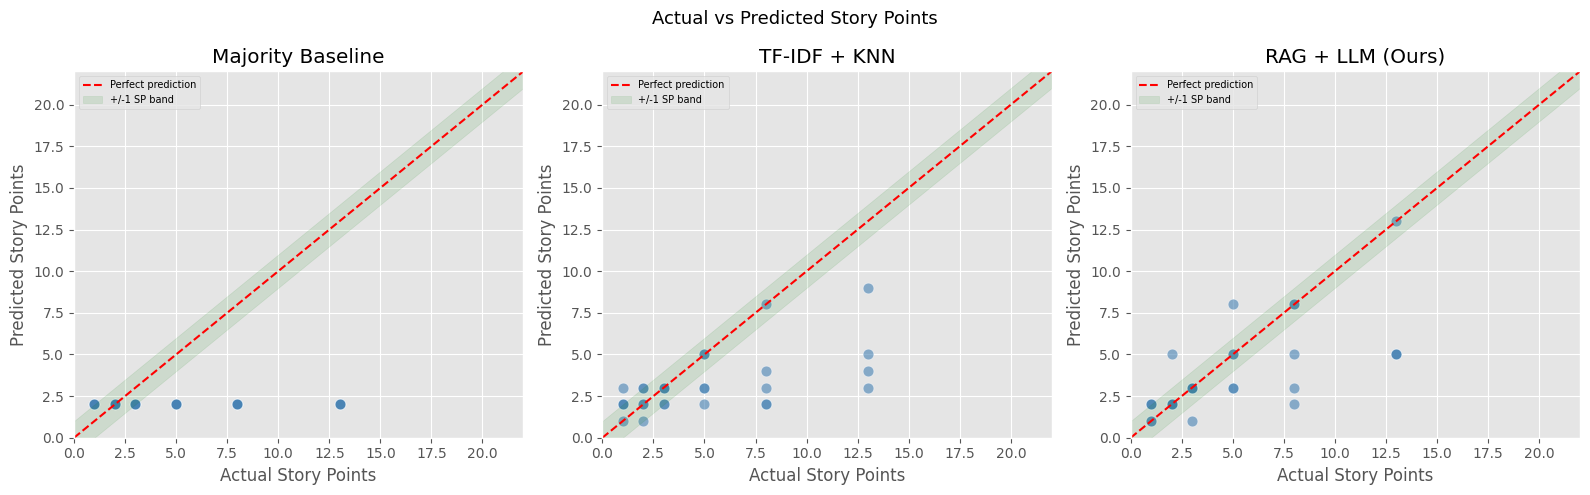

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_configs = [
    (eval_majority_aligned, rag_actual, "Majority Baseline"),
    (eval_knn_aligned, rag_actual, "TF-IDF + KNN"),
    (rag_predicted, rag_actual, "RAG + LLM (Ours)"),
]

for ax, (pred, actual, title) in zip(axes, plot_configs):
    ax.scatter(actual, pred, alpha=0.6, s=60, color="steelblue", edgecolors="white", linewidths=0.5)
    ax.plot([0, 22], [0, 22], "r--", linewidth=1.5, label="Perfect prediction")
    ax.fill_between([0, 22], [-1, 21], [1, 23], alpha=0.1, color="green", label="+/-1 SP band")
    ax.set_title(title)
    ax.set_xlabel("Actual Story Points")
    ax.set_ylabel("Predicted Story Points")
    ax.set_xlim(0, 22)
    ax.set_ylim(0, 22)
    ax.legend(fontsize=7)

plt.suptitle("Actual vs Predicted Story Points", fontsize=13)
plt.tight_layout()
plt.show()

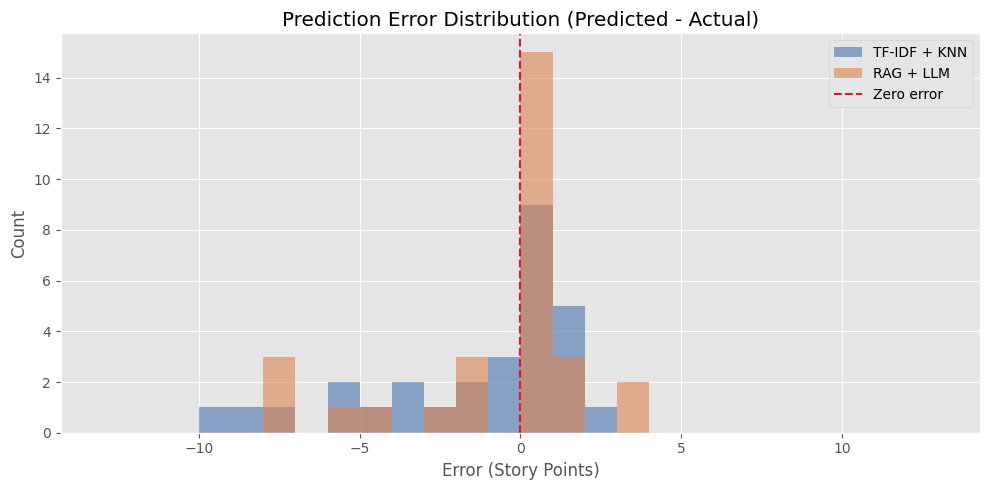

In [27]:
errors_knn = eval_knn_aligned.astype(float) - rag_actual.astype(float)
errors_rag = rag_predicted.astype(float) - rag_actual.astype(float)

fig, ax = plt.subplots(figsize=(10, 5))
bins = range(-13, 14)
ax.hist(errors_knn, bins=bins, alpha=0.6, label="TF-IDF + KNN", color="#4C72B0")
ax.hist(errors_rag, bins=bins, alpha=0.6, label="RAG + LLM", color="#DD8452")
ax.axvline(0, color="crimson", linestyle="--", linewidth=1.5, label="Zero error")
ax.set_title("Prediction Error Distribution (Predicted - Actual)")
ax.set_xlabel("Error (Story Points)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

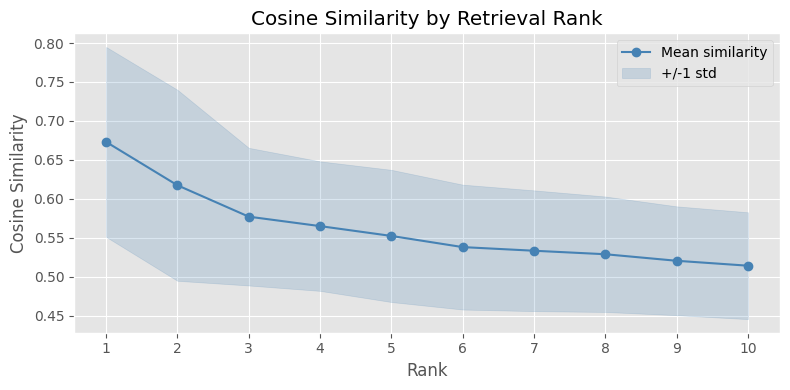

Average similarity at rank 1: 0.673
Average similarity at rank 10: 0.514

Low absolute similarity values suggest the dataset lacks close semantic neighbors for many queries,
which increases uncertainty in the retrieval step.


In [28]:
# Analyze how cosine similarity degrades across retrieval ranks
sim_records = []
sample_size = min(20, len(eval_df))
for _, row in eval_df.sample(sample_size, random_state=SEED).iterrows():
    examples = retrieve_similar(row["text"], k=K_RETRIEVAL)
    for rank, ex in enumerate(examples):
        sim_records.append({"rank": rank + 1, "similarity": ex["similarity"]})

sim_df = pd.DataFrame(sim_records)
avg_sim = sim_df.groupby("rank")["similarity"].agg(["mean", "std"]).reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(avg_sim["rank"], avg_sim["mean"], marker="o", color="steelblue", label="Mean similarity")
ax.fill_between(
    avg_sim["rank"],
    avg_sim["mean"] - avg_sim["std"],
    avg_sim["mean"] + avg_sim["std"],
    alpha=0.2, color="steelblue", label="+/-1 std"
)
ax.set_title("Cosine Similarity by Retrieval Rank")
ax.set_xlabel("Rank")
ax.set_ylabel("Cosine Similarity")
ax.set_xticks(range(1, K_RETRIEVAL + 1))
ax.legend()
plt.tight_layout()
plt.show()

print("Average similarity at rank 1: {:.3f}".format(avg_sim.loc[0, "mean"]))
print("Average similarity at rank {}: {:.3f}".format(K_RETRIEVAL, avg_sim.iloc[-1]["mean"]))
print("\nLow absolute similarity values suggest the dataset lacks close semantic neighbors for many queries,")
print("which increases uncertainty in the retrieval step.")

LLM Confidence Calibration:


,Mean Absolute Error,Count
confidence,,
high,0.954545,22
medium,4.571429,7


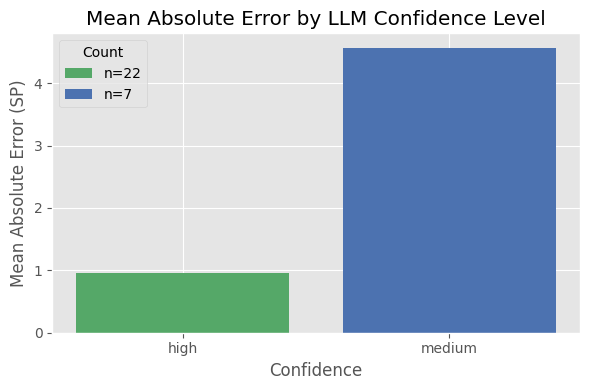

Well-calibrated confidence means high-confidence predictions should have lower MAE.


In [29]:
if "confidence" in rag_eval_df.columns and len(rag_eval_df) > 0:
    conf_analysis = (
        rag_eval_df.groupby("confidence")["error"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "Mean Absolute Error", "count": "Count"})
        .sort_values("Mean Absolute Error")
    )
    print("LLM Confidence Calibration:")
    display(conf_analysis)

    colors = {"low": "#DD8452", "medium": "#4C72B0", "high": "#55A868"}
    fig, ax = plt.subplots(figsize=(6, 4))
    for confidence, row in conf_analysis.iterrows():
        ax.bar(str(confidence), row["Mean Absolute Error"],
               color=colors.get(str(confidence), "gray"),
               label="n={}".format(int(row["Count"])))
    ax.set_title("Mean Absolute Error by LLM Confidence Level")
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Mean Absolute Error (SP)")
    ax.legend(title="Count")
    plt.tight_layout()
    plt.show()
    print("Well-calibrated confidence means high-confidence predictions should have lower MAE.")

In [30]:
demo_stories = [
    {
        "title": "Fix typo in error message",
        "text": "As a developer, I want to correct the typo in the 404 error message so that the UI text is professional.",
    },
    {
        "title": "Add dark mode to settings",
        "text": "As a user, I want a dark mode option in the settings page so that I can reduce eye strain when using the app at night.",
    },
    {
        "title": "Integrate Stripe payment gateway",
        "text": "As a user, I want to pay for my subscription via credit card using Stripe so that the checkout process is secure and seamless.",
    },
    {
        "title": "Real-time push notification system",
        "text": "As a user, I want to receive real-time push notifications for messages and activity updates so that I stay informed without manually refreshing the page.",
    },
    {
        "title": "Migrate production database to PostgreSQL",
        "text": "As an engineering team, we need to migrate the entire production database from MySQL to PostgreSQL, including schema conversion, data migration scripts, and validation.",
    },
]

sep = "=" * 60
print(sep)
print("Multi-Story Estimation Demo")
print(sep)

for item in demo_stories:
    result = estimate_story_points(item["text"])
    print("\n[{}]".format(item["title"]))
    print("  Estimate   : {} SP".format(result["estimate"]))
    print("  Confidence : {}".format(result["confidence"]))
    print("  Reasoning  : {}...".format(result["justification"][:250]))

Multi-Story Estimation Demo

[Fix typo in error message]
  Estimate   : 1 SP
  Confidence : high
  Reasoning  : This story is a straightforward typo correction in a 404 error message. The scope is minimal: locate the typo, fix the text, and verify the change. This matches the pattern of Examples 2, 3, 7, and 10, which are all simple typo fixes rated at 1 SP. T...

[Add dark mode to settings]
  Estimate   : 3 SP
  Confidence : high
  Reasoning  : The new story requests a dark mode option in the settings page. This is a moderately scoped feature that involves: (1) adding a toggle/option to the settings UI, (2) implementing the dark mode theme application, and (3) persisting the user's preferen...

[Integrate Stripe payment gateway]
  Estimate   : 8 SP
  Confidence : high
  Reasoning  : This story involves implementing a complete Stripe credit card payment integration for subscription checkout. Analysis of similar examples shows: (1) Research/configuration tasks are 1 SP (Examples 1, 2, 4

## 8. Conclusions & Next Steps

**Key Findings**

- The dataset contains 20,474 issues from 33 projects, with story points ranging from 0 to 300 across 82 distinct values. Only 72.9% of records fall on the standard Fibonacci scale, and after filtering to Fibonacci values the distribution is severely imbalanced: classes 1 and 2 together account for 65.2% of records, while class 21 has only 5 examples and class 13 has 71.
- Text length increases monotonically with story points (840 characters at 1 SP, 1,825 at 21 SP), confirming that richer descriptions correlate with larger, more complex tasks. This is consistent with the intuition that high-effort stories require more specification.
- Description coverage is high: only 7.9% of issues (1,629 of 20,474) are title-only. The embedding model therefore has adequate context for the majority of records.
- Estimation patterns vary substantially across the 33 projects, reflecting different team conventions and task granularity. A single global retrieval index must account for this cross-project heterogeneity.

**Model Performance vs Success Criteria**

The evaluation was conducted on a stratified 29-story sample (5 per class for SP 1-8, 4 for SP 13) to isolate performance from class imbalance. Results on the sample:

| System | MAE | RMSE | Acc ±1 | Acc ±2 |
|---|---|---|---|---|
| Majority Baseline | 3.414 | 4.979 | 51.7% | 51.7% |
| TF-IDF + KNN | 2.379 | 3.728 | 58.6% | 69.0% |
| RAG + LLM (Ours) | 1.828 | 3.189 | 62.1% | 72.4% |

The RAG + LLM system achieves the best result on all metrics. The success criterion, Acc ±1 above 60%, is met at 62.1%. Structured JSON justifications were returned for all 29 evaluation calls, meeting the third criterion.

A noteworthy discrepancy appears when evaluating baselines on the full test set (n=747): the majority baseline reaches Acc ±1 of 85.7%, while TF-IDF + KNN achieves only 79.5%. This inversion occurs because the full test set is dominated by 1 and 2 SP values, so always predicting 2 trivially falls within ±1 of most true labels. The stratified sample corrects for this, producing a more informative comparison.

**Interpretation**

The confidence calibration reveals that the LLM's stated uncertainty is a meaningful signal. For the 22 high-confidence predictions, MAE was 0.954, which satisfies the 1.5 SP target. For the 7 medium-confidence predictions, MAE was 4.571, indicating that the model recognizes when the retrieval provides insufficient grounding and signals this correctly. No low-confidence predictions were produced. In a practical deployment, filtering to high-confidence estimates and flagging the rest for human review would yield estimates well within the target accuracy, while affecting roughly 24% of queries.

The multi-story demo illustrates that the system handles the full complexity range coherently: a typo fix is estimated at 1 SP (high confidence), a dark mode feature at 3 SP, Stripe integration at 8 SP, and a full MySQL-to-PostgreSQL database migration at 21 SP (medium confidence), all with justifications that explicitly reference retrieved historical examples.

**Limitations**

- Class imbalance is severe: class 21 has 5 training examples, class 13 has 71. The model has almost no historical signal for large stories and is likely to underestimate them. The test set contained no SP=21 examples at all due to the small sample size.
- Retrieval similarity values are moderate, with rank-1 average cosine similarity of 0.673 dropping to 0.514 at rank 10. This narrow range and moderate absolute magnitude indicate that many queries have no truly close neighbors in the corpus, forcing the LLM to generalize from loosely related examples and increasing uncertainty.
- The index mixes 33 projects with different team conventions and estimation scales. A story retrieved from a different project may have the same text similarity but a different calibration of what "3 SP" means, introducing systematic noise.
- The evaluation sample has only 29 stories, making all reported metrics subject to high variance. The absence of SP=21 in the test set leaves the hardest class entirely unevaluated.
- The 8% of title-only issues provide sparse input to the embedding model, likely resulting in lower retrieval quality for those cases.

**Next Steps**

- Address class imbalance through oversampling of rare classes (13, 21 SP) or by training a dedicated retrieval model that up-weights underrepresented effort levels.
- Build per-project retrieval indexes and route each query to its project-specific index when available. A fallback to the global index can handle unseen projects.
- Replace `all-MiniLM-L6-v2` with a domain-adapted encoder fine-tuned on software issue text, such as a model further trained on GitHub or Jira corpora, to close the gap between rank-1 and rank-10 similarity scores.
- Use the confidence signal operationally: route medium-confidence estimates to a human estimator rather than returning them directly, reducing the effective MAE on accepted predictions below 1.0 SP.
- Expand the evaluation set to at least 200 stratified examples to obtain stable metric estimates, and include SP=21 examples by holding out at least 2 of the 5 available records.